# Dependecies

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare the Dataset

In [50]:
df = pd.read_csv('Data/ultimate_student_productivity_dataset_5000.csv')
df.drop('student_id', axis=1, inplace=True)
df.head(2)

,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,18,Other,High School,7.64,1.56,2.2,3.05,2.19,6.52,6.47,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,18,Other,High School,2.21,2.22,2.1,1.65,2.55,5.97,6.05,111,339,0,0,Good,3,15.92,37.00,13.70,1.00


In [51]:
target_col = "productivity_score"

categorical_cols = ["gender", "academic_level", "internet_quality"]
binary_cols = ["part_time_job", "upcoming_deadline"]

numeric_cols = [
    "age", "study_hours", "self_study_hours", "online_classes_hours",
    "social_media_hours", "gaming_hours", "sleep_hours",
    "screen_time_hours", "exercise_minutes", "caffeine_intake_mg",
    "mental_health_score", "focus_index", "burnout_level", "exam_score"
]

In [52]:
# 3. Ordinal Encoding
academic_map = {'High School': 0, 'Undergraduate': 1, 'Postgraduate': 2}
internet_map = {'Poor': 0, 'Average': 1, 'Good': 2}
df['academic_level'] = df['academic_level'].map(academic_map)
df['internet_quality'] = df['internet_quality'].map(internet_map)

# Use this for Linear Regression
df = pd.get_dummies(df, columns=['gender'], prefix='gender', dtype=int, drop_first=True)
# df = pd.get_dummies(df, columns=["gender","academic_level","internet_quality"], drop_first=True)

In [53]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 4000 samples
Testing set: 1000 samples


In [54]:
scaler = StandardScaler()

# Fit ONLY on training numeric columns
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform test numeric columns using train statistics
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [55]:
X_train_array = X_train.to_numpy()
y_train_array = y_train.to_numpy().reshape(-1, 1)

X_test_array = X_test.to_numpy()
y_test_array = y_test.to_numpy().reshape(-1, 1)


print("shape of X train: ",X_train_array.shape)
print('Shape of y train: ',y_train_array.shape)

print("shape of X test: ",X_test_array.shape)
print('Shape of y test: ',y_test_array.shape)

shape of X train:  (4000, 20)
Shape of y train:  (4000, 1)
shape of X test:  (1000, 20)
Shape of y test:  (1000, 1)


# LR


In [62]:
class LinearRegression:
    def __init__(self, learning_rate = .01, iterations = 10000):
        self.lr  = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_histroy = None
    
    def _compute_cost(self,y_prediction,y):
        n_samples = y_prediction.shape[0]
        cost = (1/(2*n_samples)) * np.sum((y_prediction - y)**2)
        return cost
    
    def compute_gradient(self, X, y_prediction, y):
        n_samples = y.shape[0]

        dw = (1/n_samples) * X.T @ (y_prediction - y)
        db = (1/n_samples) * np.sum(y_prediction - y)

        return dw, db

    def gradient_descent(self, dw, db):
        self.weights = self.weights - self.lr * dw
        self.bias = self.bias - self.lr * db

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0
        self.cost_histroy = np.zeros(self.iterations)

        for i in range(self.iterations):
            y_prediction = X@self.weights + self.bias
            j = self._compute_cost(y_prediction, y)
            self.cost_histroy[i] = j

            dw,db  = self.compute_gradient(X,y_prediction,y)
            self.gradient_descent(dw,db)

    def predict(self, X):
        y_prediction = X @ self.weights + self.bias
        return y_prediction


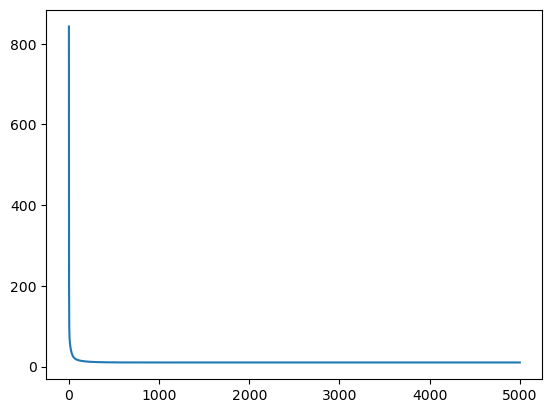

In [65]:
lr = LinearRegression(learning_rate = 1e-1, iterations = 5000)
lr.fit(X_train_array,y_train_array)
lr.predict(X_train_array)

plt.plot(lr.cost_histroy)
